# ProteinMPNN supercharging benchmark

Analysis notebook for the benchmark described in `PLAN.md`. It answers the three
peer reviews with the numbers in `results/`.

**This notebook reads only `results/*.csv` and `data/scaffold_manifest.csv`, and
writes only `figures/` and `tables/`.** It does not touch the cluster, import
torch or pyrosetta, or recompute a metric. It runs top to bottom on a fresh
kernel with no cluster access. If a number appears in a figure here, it was
computed by a script in `scripts/` from a file on disk and written to a CSV.

Section numbers refer to `PLAN.md`.

## 1. Setup, style, data load, schema assertions

In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import pandas as pd

import analysis_lib as A
import tables_lib as T

A.set_style()
data = A.load_all()

designs.csv: 10560 designs, 25 scaffolds, 6 methods
  threaded: 1992   predicted: 10560


In [2]:
# Schema assertions live in A.load(); this cell reports what is actually present
# so a partially complete run is obvious rather than showing up as empty panels.
d = data["designs"]
coverage = pd.DataFrame({
    "column": ["threaded (thread_tier)", "ESMFold (plddt_mean)",
               "energetics (d_reu_per_res)", "AF3 (af3_plddt)"],
    "n_designs": [d["thread_tier"].notna().sum(), d["plddt_mean"].notna().sum(),
                  d["d_reu_per_res"].notna().sum(),
                  d["af3_plddt"].notna().sum() if "af3_plddt" in d else 0],
})
coverage["fraction"] = (coverage["n_designs"] / len(d)).round(4)
coverage

,column,n_designs,fraction
0,threaded (thread_tier),1992,0.1886
1,ESMFold (plddt_mean),10560,1.0000
2,energetics (d_reu_per_res),1992,0.1886
3,AF3 (af3_plddt),32,0.0030


## 2. Scaffold panel

Phase 1 selected 25 scaffolds across three fold classes. `loop_rich` was dropped
(Decision 11): every scaffold satisfying its coil threshold also satisfied
`alpha_beta`, which precedes it, so the class could never receive a member.

In [3]:
t1 = T.table1(data)
t1.groupby("fold_class").agg(
    n=("scaffold_id", "size"),
    residues=("n_residues", lambda s: f"{s.min()}-{s.max()}"),
    q_wt=("q_wt", lambda s: f"{s.min():+d} to {s.max():+d}"),
    designable=("n_designable", lambda s: f"{s.min()}-{s.max()}"),
)

wrote tables/T1_scaffold_panel.csv and .tex  (25 rows)


,n,residues,q_wt,designable
fold_class,,,,
alpha_beta,8,80-197,-9 to +10,49-80
mainly_alpha,8,80-142,-9 to +14,53-87
mainly_beta,8,101-227,-7 to +2,47-88


## 3. Charge-targeting accuracy

F1. Exact-hit rate against |ΔQ density|, one line per method, Wilson 95% CI
ribbons, faceted by fold class.

wrote figures/F1_hit_rate_by_fold_class.png and .pdf


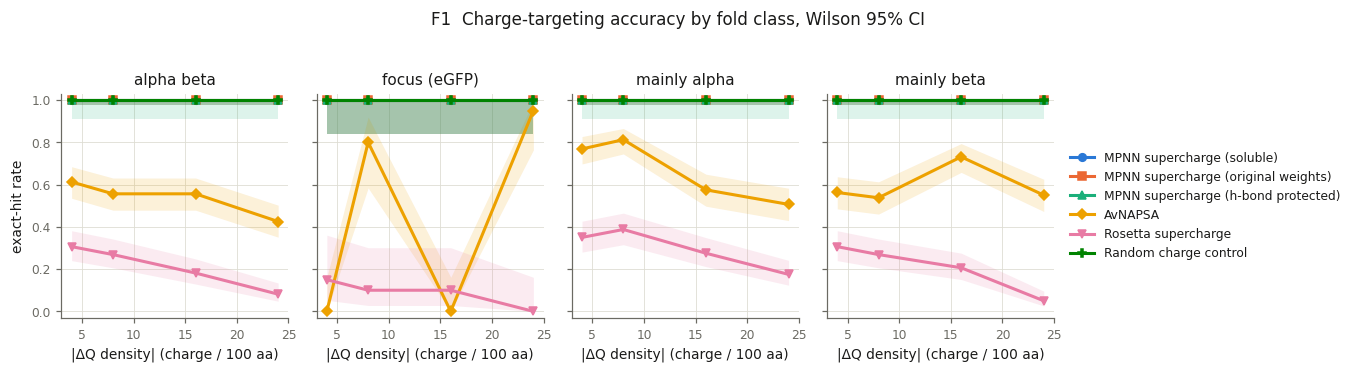

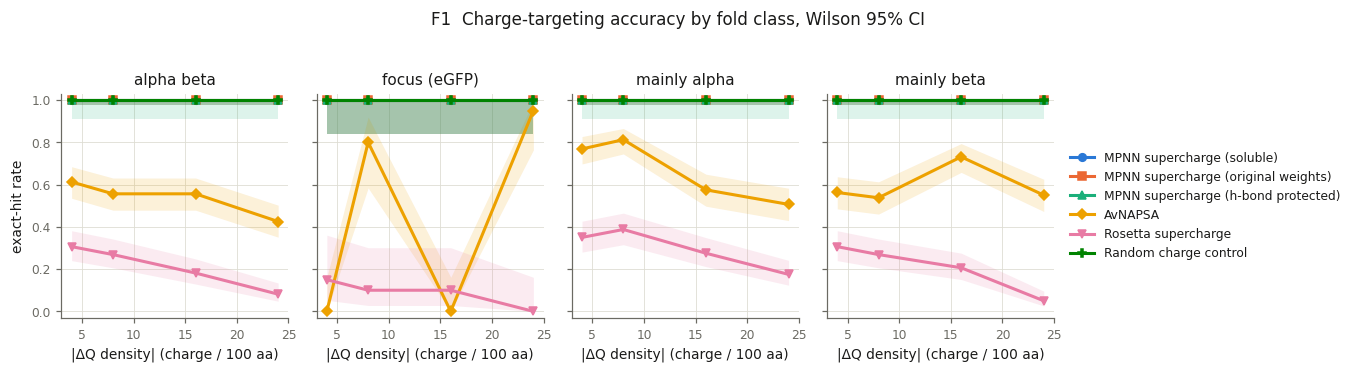

In [4]:
fig = A.fig1(data); A.save(fig, "F1_hit_rate_by_fold_class"); fig

In [5]:
# The headline numbers behind F1, per method.
(d.groupby("method")
   .agg(n_designs=("design_id", "size"),
        hit_rate=("hit_exact", "mean"),
        mean_abs_error=("q_error_abs", "mean"))
   .reindex([m for m in A.METHOD_ORDER if m in set(d["method"])]))

,n_designs,hit_rate,mean_abs_error
method,,,
mpnn_soluble,2000,1.000,0.0000
mpnn_vanilla_weights,2000,1.000,0.0000
mpnn_soluble_hbond_protected,560,1.000,0.0000
avnapsa,2000,0.593,0.5220
rosetta,2000,0.232,2.9335
random_control,2000,1.000,0.0000


## 4. The rejection-sampling ablation

**This is the section that answers R3.** The question is not whether vanilla
ProteinMPNN plus a charge filter is slower, it is whether it reaches the targets
at all.

F2 plots the fraction of 2,000 vanilla samples per scaffold landing exactly on
each target, against the supercharging method's rate. F3 shows why: the ladder
sits far outside the mass the base model samples.

/projectsp/f_sdk94_1/als515/mpnn-supercharging/Benchmark/notebooks/analysis_lib.py:260: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pooled = curve.groupby("abs_density").apply(


wrote figures/F2_rejection_yield.png and .pdf


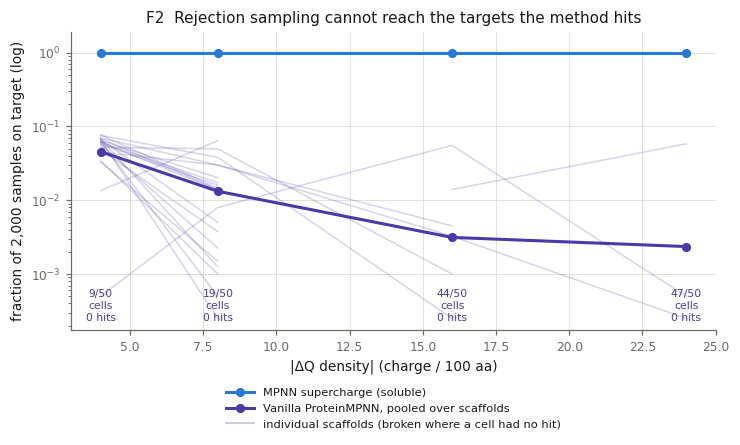

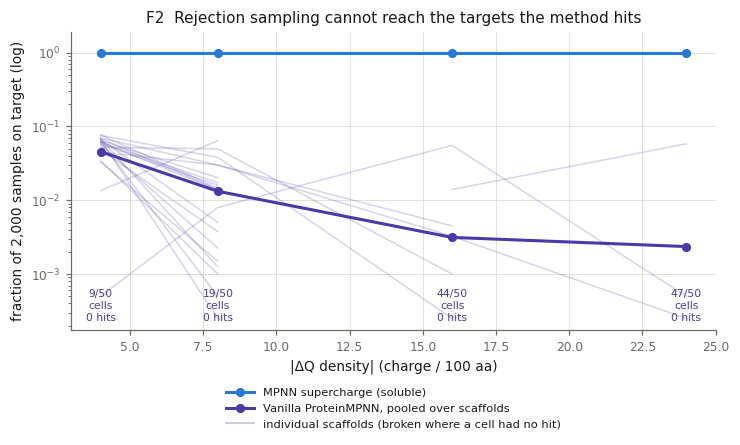

In [6]:
fig = A.fig2(data); A.save(fig, "F2_rejection_yield"); fig

wrote figures/F2_inset_cost_per_hit.png and .pdf


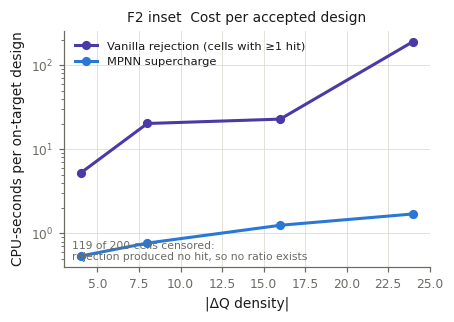

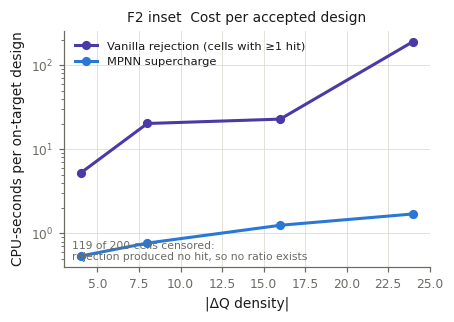

In [7]:
fig = A.fig2_inset_cost(data); A.save(fig, "F2_inset_cost_per_hit"); fig

In [8]:
curve = data["curve"]
summary = (curve.assign(zero=curve["n_on_target"] == 0)
           .groupby("delta_q_density")
           .agg(cells=("zero", "size"), cells_with_zero_hits=("zero", "sum"),
                total_on_target=("n_on_target", "sum")))
summary["pct_cells_zero"] = (100 * summary["cells_with_zero_hits"] / summary["cells"]).round(1)
print(f"{int(summary.cells_with_zero_hits.sum())} of {int(summary.cells.sum())} "
      f"cells got zero on-target samples out of "
      f"{int(curve.n_samples_drawn.max())} draws each")
summary

119 of 200 cells got zero on-target samples out of 2000 draws each


,cells,cells_with_zero_hits,total_on_target,pct_cells_zero
delta_q_density,,,,
-24,25,22,236,88.0
-16,25,19,314,76.0
-8,25,7,1138,28.0
-4,25,1,3190,4.0
4,25,8,1362,32.0
8,25,12,188,48.0
16,25,25,0,100.0
24,25,25,0,100.0


wrote figures/F3_vanilla_charge_distribution.png and .pdf


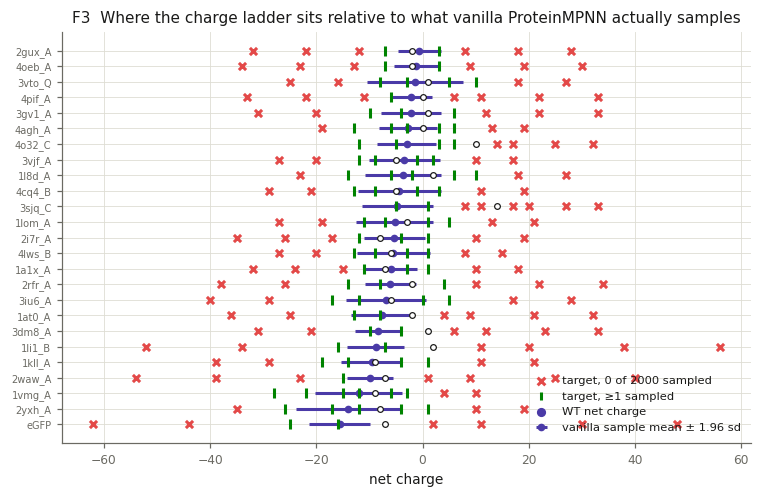

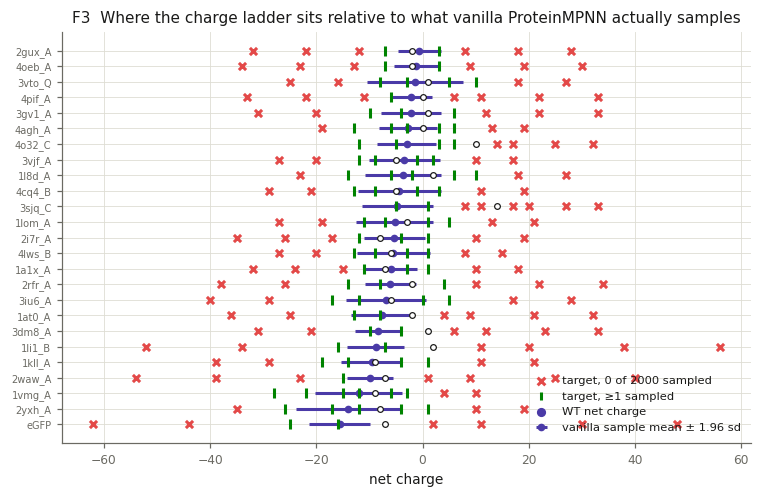

In [9]:
fig = A.fig3(data); A.save(fig, "F3_vanilla_charge_distribution"); fig

In [10]:
# The base model's own charge bias, which is what makes the positive rungs
# unreachable rather than merely rare.
dist = data["dist"]
bias = dist.assign(shift=dist["q_mean"] - dist["q_wt"])
print(f"scaffolds sampling MORE positive than wild type: "
      f"{(bias['shift'] > 0).sum()} of {len(bias)}")
bias[["scaffold_id", "q_wt", "q_mean", "q_sd", "shift"]].sort_values("shift").head(10)

scaffolds sampling MORE positive than wild type: 7 of 25


,scaffold_id,q_wt,q_mean,q_sd,shift
15,3sjq_C,14,-4.7775,3.4323,-18.7775
21,4o32_C,10,-3.0210,2.8045,-13.0210
4,1li1_B,2,-8.8475,2.7194,-10.8475
12,3dm8_A,1,-8.3785,2.2625,-9.3785
24,eGFP,-7,-15.6410,2.9349,-8.6410
11,2yxh_A,-8,-14.0370,5.0200,-6.0370
3,1l8d_A,2,-3.7720,3.6524,-5.7720
1,1at0_A,-2,-7.6505,2.9698,-5.6505
9,2rfr_A,-2,-6.0765,2.4382,-4.0765
13,3gv1_A,1,-2.2305,2.8757,-3.2305


## 5. Mutational efficiency

F4. Mutations per unit of charge actually moved, with Der et al. 2013's reference
values annotated (0.6 for AvNAPSA, 0.85 for Rosetta).

wrote figures/F4_mutations_per_charge.png and .pdf


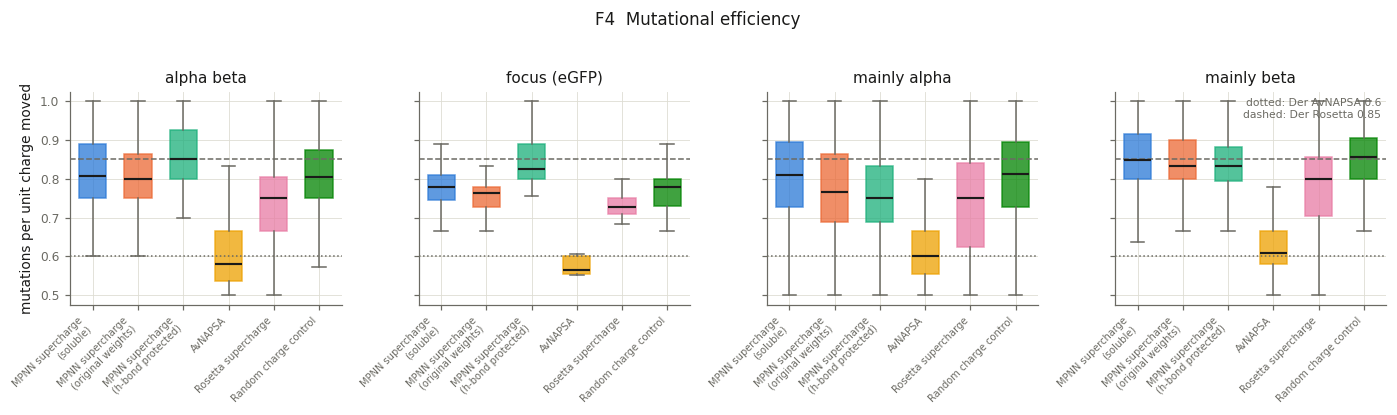

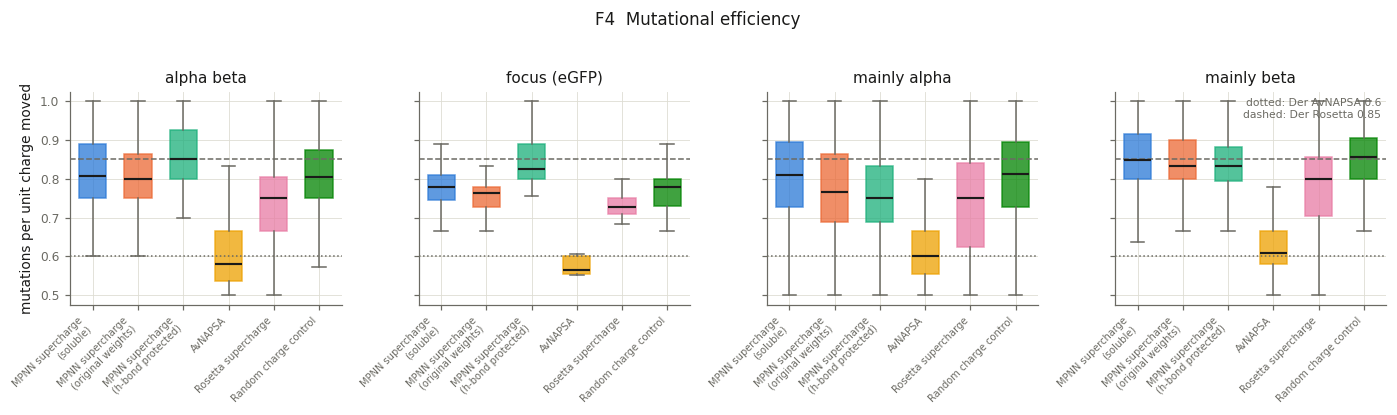

In [11]:
fig = A.fig4(data); A.save(fig, "F4_mutations_per_charge"); fig

## 6. Sequence diversity

F5. The four Section 10.2 metrics, all restricted to designable positions.

Read the AvNAPSA column carefully: that arm produced one design per cell, so its
unique-set count is 1 **by construction** and its pairwise Hamming distance and
positional entropy are undefined, not zero. This does not show that AvNAPSA is
deterministic; the benchmark did not test that.

wrote figures/F5_diversity_panel.png and .pdf


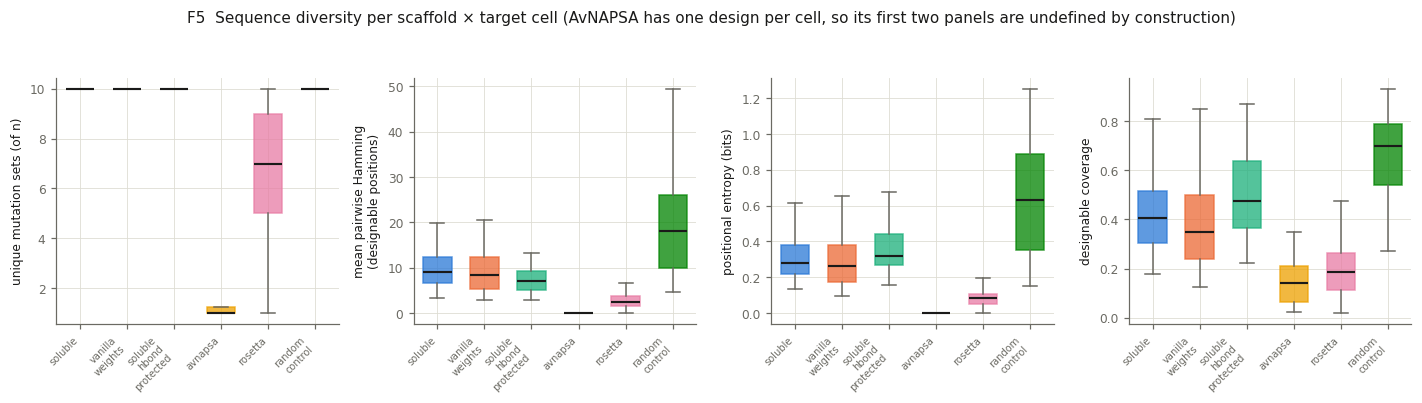

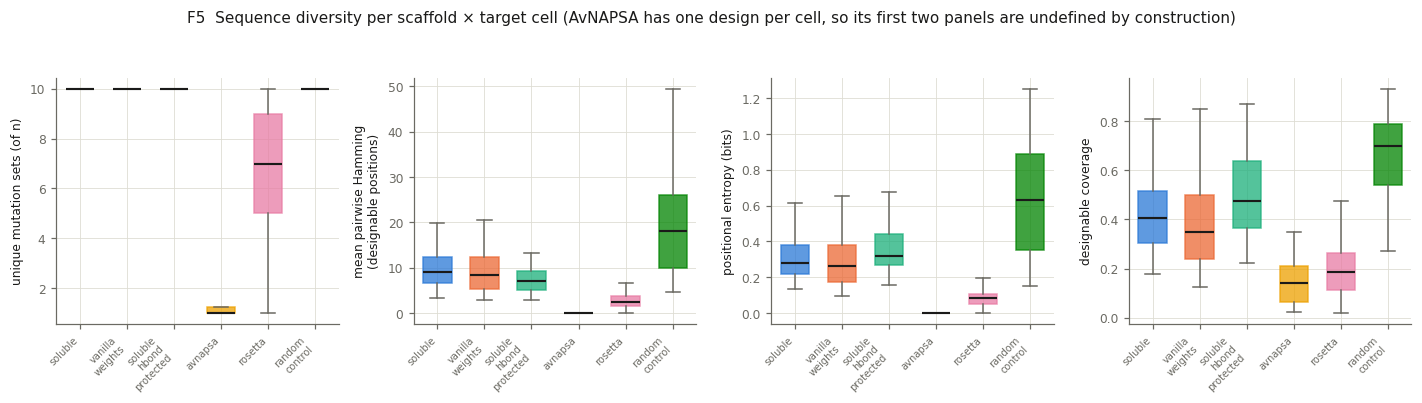

In [12]:
fig = A.fig5(data); A.save(fig, "F5_diversity_panel"); fig

In [13]:
s = data["summary"]
(s.groupby("method")
  .agg(n_cells=("scaffold_id", "size"),
       unique_sets=("n_unique_mutation_sets", "median"),
       pairwise_hamming=("mean_pairwise_hamming", "median"),
       positional_entropy=("positional_entropy", "median"),
       designable_coverage=("designable_coverage", "median"))
  .reindex([m for m in A.METHOD_ORDER if m in set(s["method"])]))

,n_cells,unique_sets,pairwise_hamming,positional_entropy,designable_coverage
method,,,,,
mpnn_soluble,200,10.0,9.133333,0.279601,0.405084
mpnn_vanilla_weights,200,10.0,8.355556,0.263342,0.349206
mpnn_soluble_hbond_protected,56,10.0,7.066667,0.320383,0.474955
avnapsa,200,1.0,0.000000,0.000000,0.139444
rosetta,200,7.0,2.466667,0.082114,0.187500
random_control,200,10.0,18.122222,0.630271,0.698413


## 7. Energetics

F6 and F7. All REU values are deltas against a **relaxed** wild-type reference,
one per scaffold per threading tier.

The reference had to be built by this benchmark rather than by the repo's
`threading_only.py`, which does not relax a zero-mutation sequence. Referencing
against the unrelaxed crystal would have folded the whole relaxation gain, a
median of 305 REU across the panel, into every delta. See `logs/ISSUES.md` item
11, including the caveat that the reference relaxes unrestricted while designs
relax within a shell, which biases these deltas against the designs.

wrote figures/F6_delta_reu_per_residue.png and .pdf


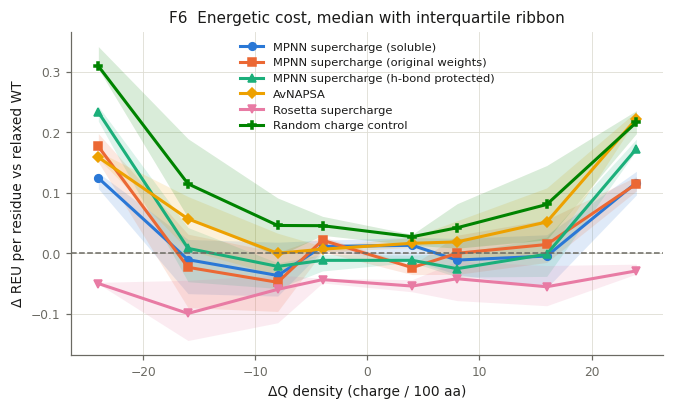

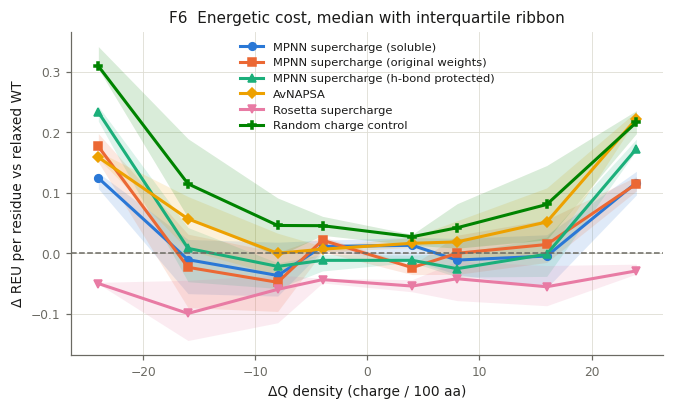

In [14]:
fig = A.fig6(data)
if fig is not None:
    A.save(fig, "F6_delta_reu_per_residue")
fig

wrote figures/F7_energy_decomposition.png and .pdf


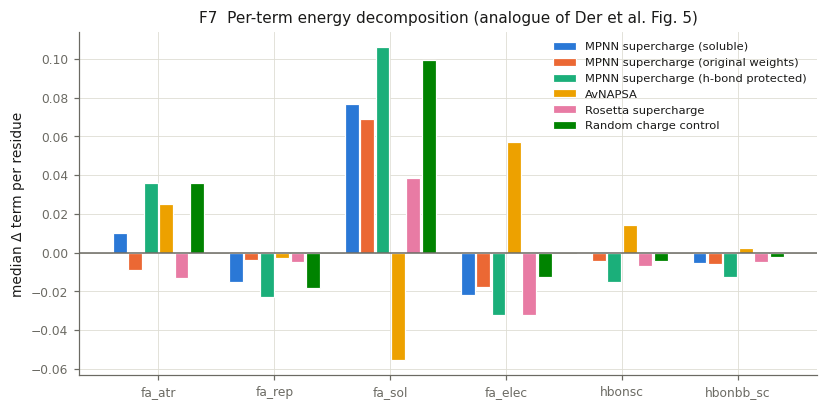

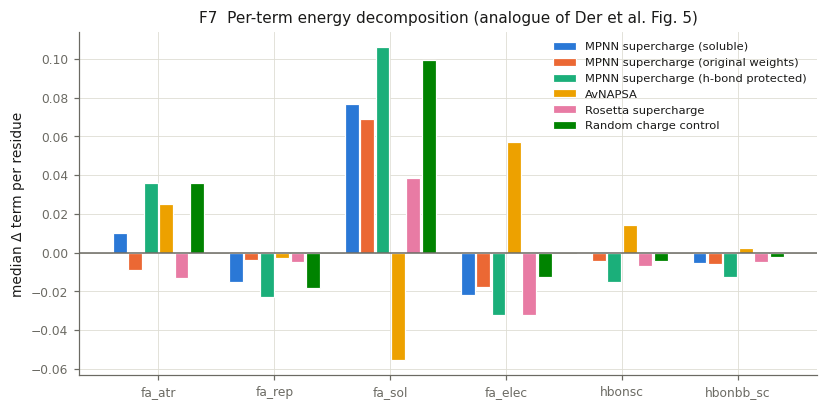

In [15]:
fig = A.fig7(data)
if fig is not None:
    A.save(fig, "F7_energy_decomposition")
fig

### F8. Sequence recovery and energetic spread (answers R7)

The plot Reviewer 3 asked for: identity to wild type at designable positions
against target charge, with the spread of ΔREU per residue on a second axis.

A twin y-axis is normally the wrong form, because two scales invite a false
reading of where the curves cross. It is used here because Section 11.1 names
this specific plot as the reviewer's request, and changing the form would answer
a different question. The crossing point carries no meaning. The cell after it
draws the same data on separate panels for anyone who prefers to read it that
way.

wrote figures/F8_recovery_and_reu_spread.png and .pdf


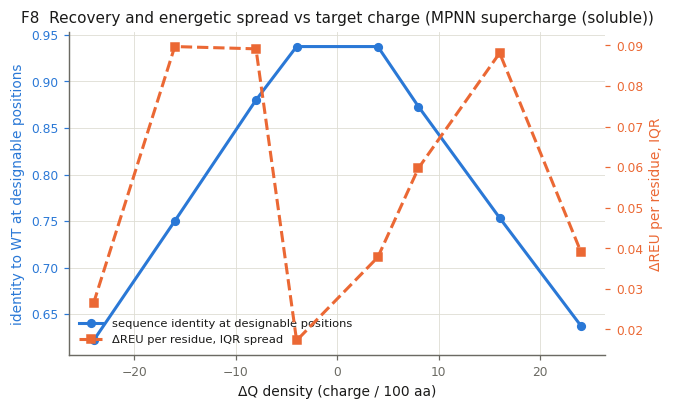

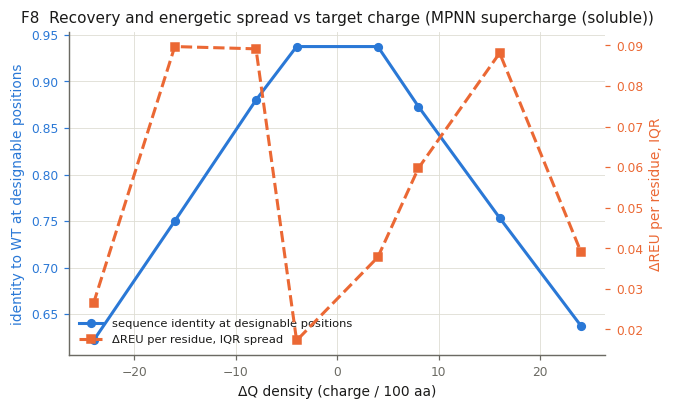

In [16]:
fig = A.fig8(data); A.save(fig, "F8_recovery_and_reu_spread"); fig

wrote figures/F8alt_recovery_small_multiples.png and .pdf


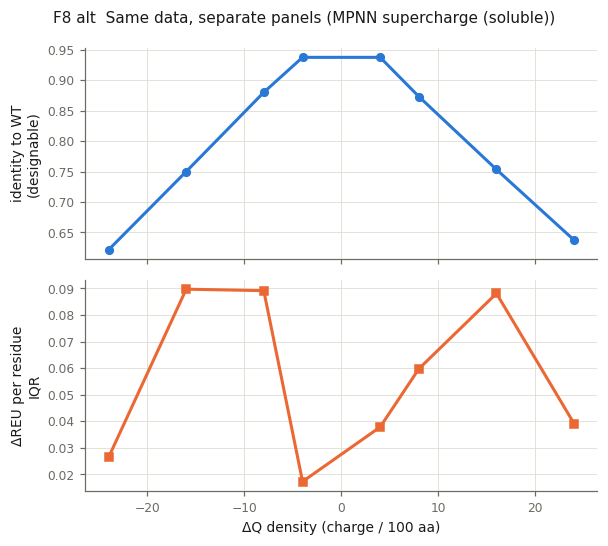

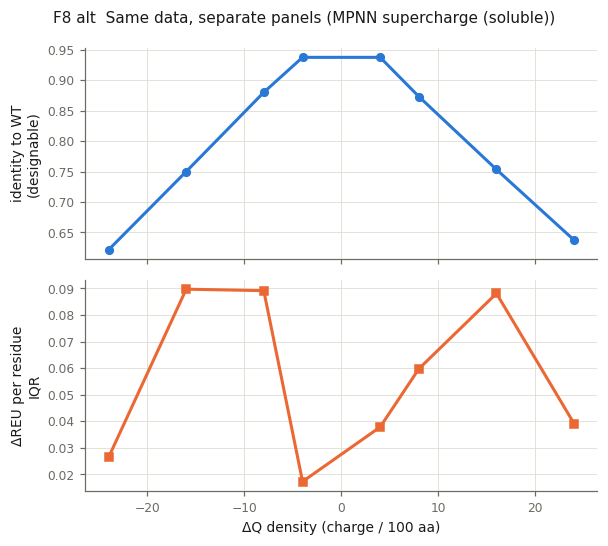

In [17]:
fig = A.fig8_small_multiples(data); A.save(fig, "F8alt_recovery_small_multiples"); fig

## 8. Hydrogen bonding

F9. Side-chain hydrogen bonds gained and lost against the matched relaxed wild
type, counted with Der et al.'s thresholds (strong ≤ −0.5 REU, weak between
−0.5 and −0.1). Backbone-to-backbone bonds are excluded: they are a property of
the fixed scaffold, not of the surface mutations.

wrote figures/F9_hydrogen_bonds.png and .pdf


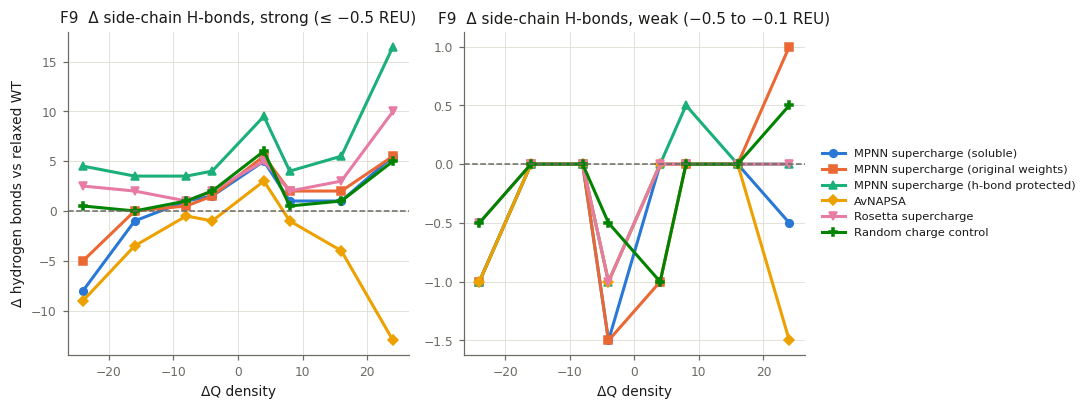

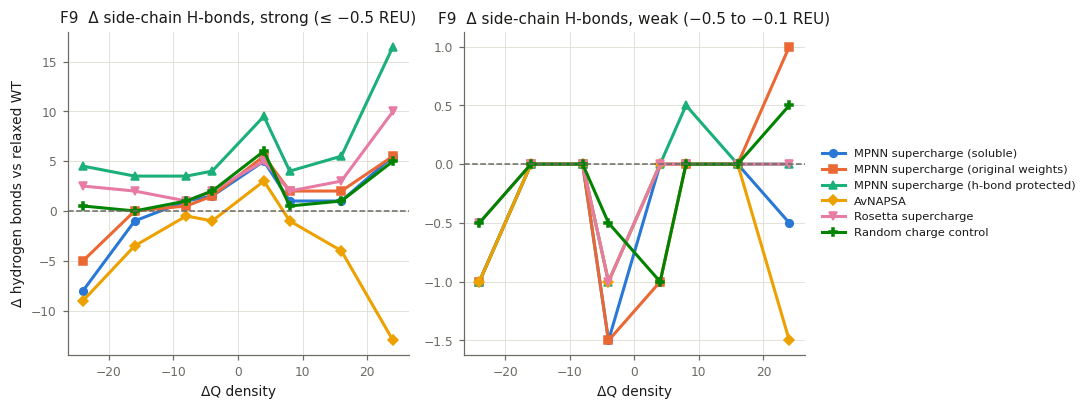

In [18]:
fig = A.fig9(data)
if fig is not None:
    A.save(fig, "F9_hydrogen_bonds")
fig

## 9. Structure prediction

F10. ESMFold2 on every design, AF3 on the stratified subset in single-sequence
mode. RMSD is to the wild-type **crystal** chain, never to the threaded model.

Faceted by method rather than overlaid: six series overlaid in a scatter form
fails the all-pairs colourblind check (`scripts/validate_palette.py --pairs all`
reports worst protan/deutan ΔE 3.2 against a floor of 6).

wrote figures/F10_structure_prediction.png and .pdf


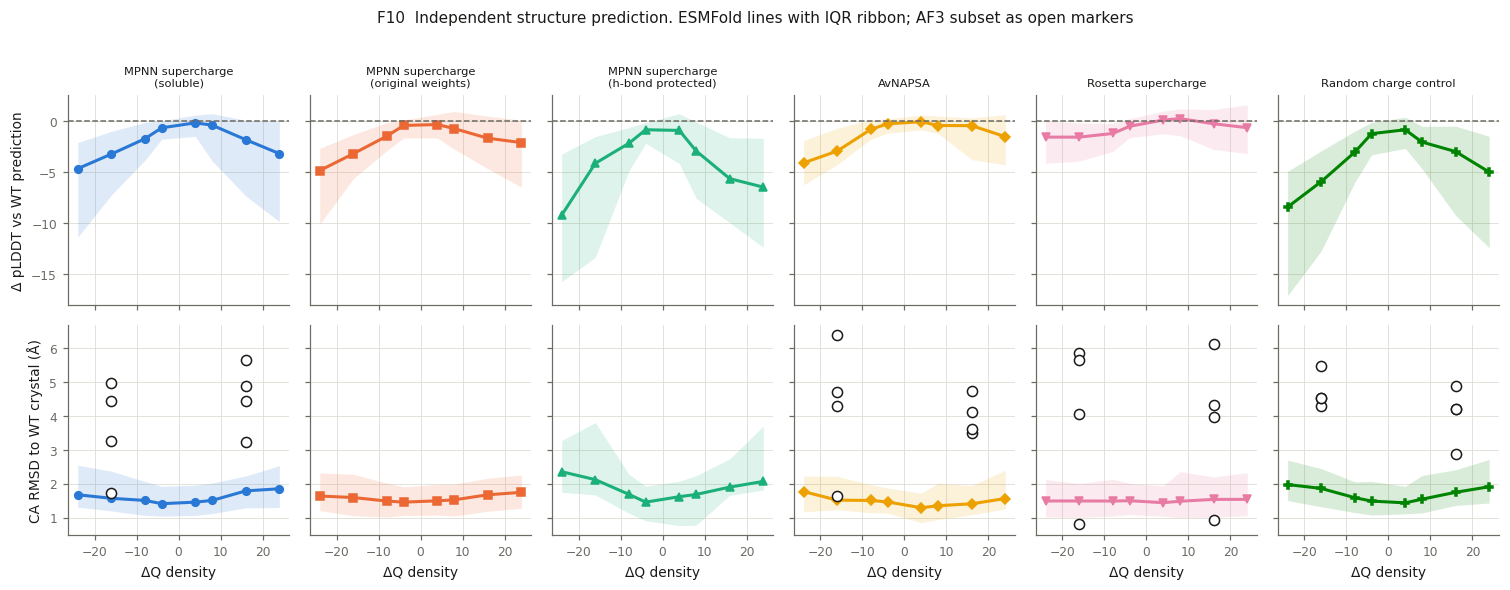

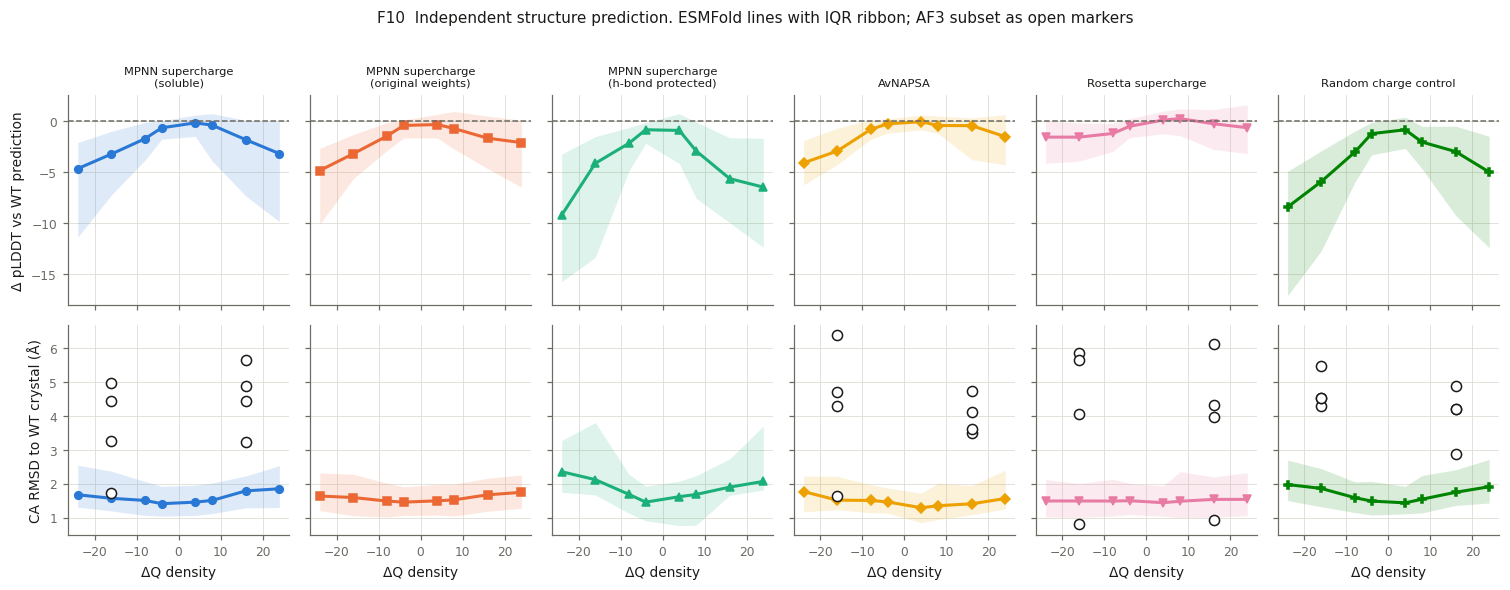

In [19]:
fig = A.fig10(data)
if fig is not None:
    A.save(fig, "F10_structure_prediction")
fig

### F14. Where predicted confidence starts to fall (Section 11.1, added 2026-08-26)

The question behind this figure was posed as "at what temperature or mutation
count does pLDDT drop below 0.8". Two things stop that being answerable in the
form it was asked, and both are shown rather than worked around.

First, 10 of the 25 wild types already predict below 80, so a design counted as
failing an absolute cutoff is usually reporting which scaffold it was built on.
Panel d shows that directly, and every other panel is stated against each
scaffold's own predicted wild type. `d_plddt_vs_wt_pred` is that difference and
is computed in Phase 6, not here.

Second, the mutation-count axis is unbalanced across scaffolds: only the longest
scaffolds reach the high bins, and those are also the ones ESMFold predicts most
confidently. Pooling designs makes the curve turn upward at 30 or more
mutations, which is the scaffold panel showing through, not a real recovery.
Every summary here is therefore the median of per-scaffold medians with the IQR
taken across scaffolds, and a bin holding fewer than `A.MIN_SCAFFOLDS_PER_BIN`
scaffolds is dropped instead of drawn thin. T7 keeps the pooled median in
`pooled_median_d_plddt` alongside, so the difference between the two is
inspectable.

T7b reduces this to the first bin on each axis where the balanced median crosses
-5 and -10 pLDDT; a method that never crosses is recorded as `none` rather than
given a number.

wrote figures/F14_plddt_dropoff.png and .pdf


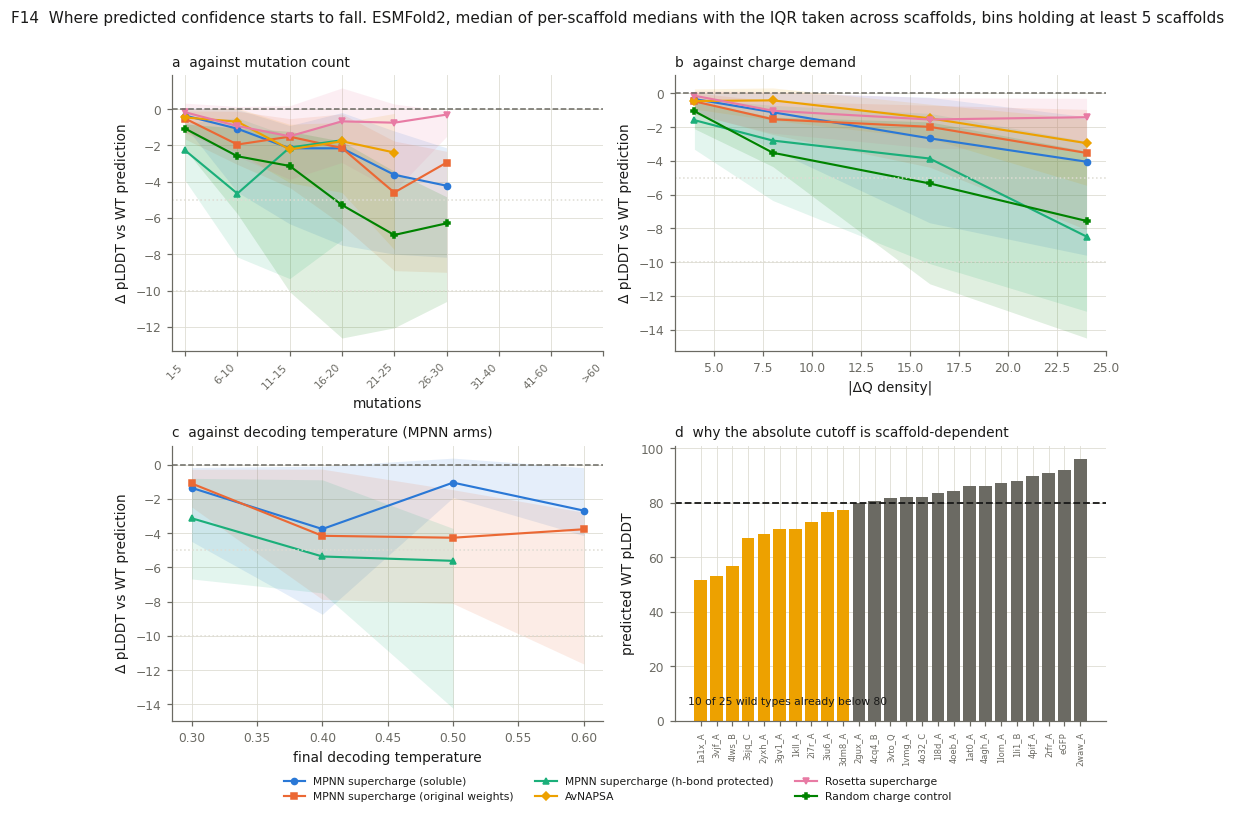

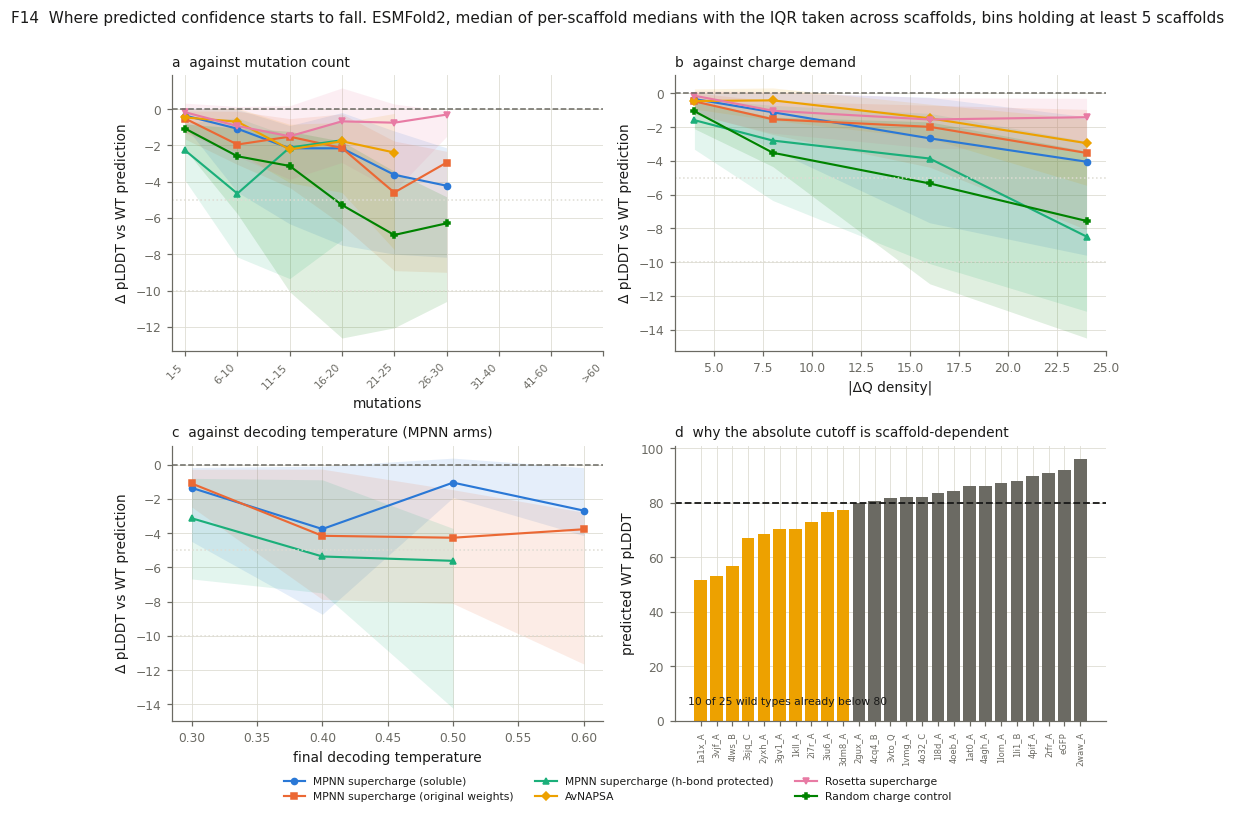

In [20]:
fig = A.fig14(data); A.save(fig, "F14_plddt_dropoff"); fig

In [21]:
t7 = T.table7(data)
# The direct answer to the question, per method, on the mutation-count axis.
import pandas as pd
cross = pd.read_csv(A.TABLES / "T7b_plddt_first_crossing.csv")
print(cross[cross["axis"] == "mutations"].to_string(index=False))
wt = A.wt_below_threshold(A.plddt_frame(data))
print(f"\npredicted WT pLDDT below {A.PLDDT_ABS_THRESHOLD:.0f} for "
      f"{int((wt < A.PLDDT_ABS_THRESHOLD).sum())} of {len(wt)} scaffolds: "
      f"{', '.join(wt[wt < A.PLDDT_ABS_THRESHOLD].index)}")

wrote tables/T7_plddt_dropoff.csv and .tex  (68 rows)
wrote tables/T7b_plddt_first_crossing.csv and .tex  (30 rows)
                      method      axis  level_d_plddt first_bin_crossing  n_designs_at_crossing  n_scaffolds_at_crossing  median_at_crossing
                mpnn_soluble mutations           -5.0               none                      0                        0                 NaN
                mpnn_soluble mutations          -10.0               none                      0                        0                 NaN
        mpnn_vanilla_weights mutations           -5.0               none                      0                        0                 NaN
        mpnn_vanilla_weights mutations          -10.0               none                      0                        0                 NaN
mpnn_soluble_hbond_protected mutations           -5.0               none                      0                        0                 NaN
mpnn_soluble_hbond_protected mutations

## 10. Charge capacity and runtime

F11 generalises manuscript Figure 2A from one protein to the whole panel. F12 is
the runtime per accepted design.

wrote figures/F11_charge_capacity.png and .pdf


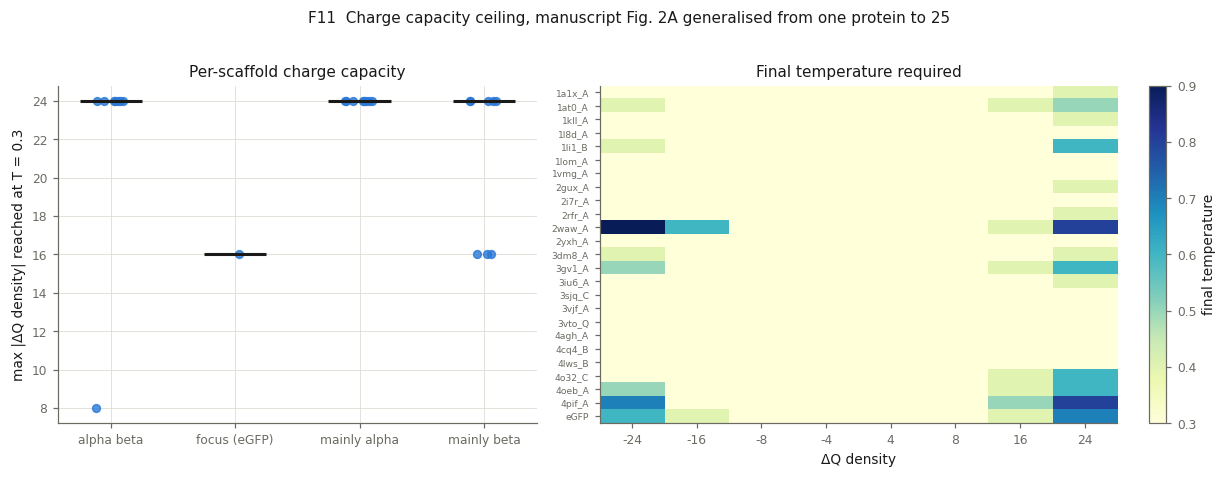

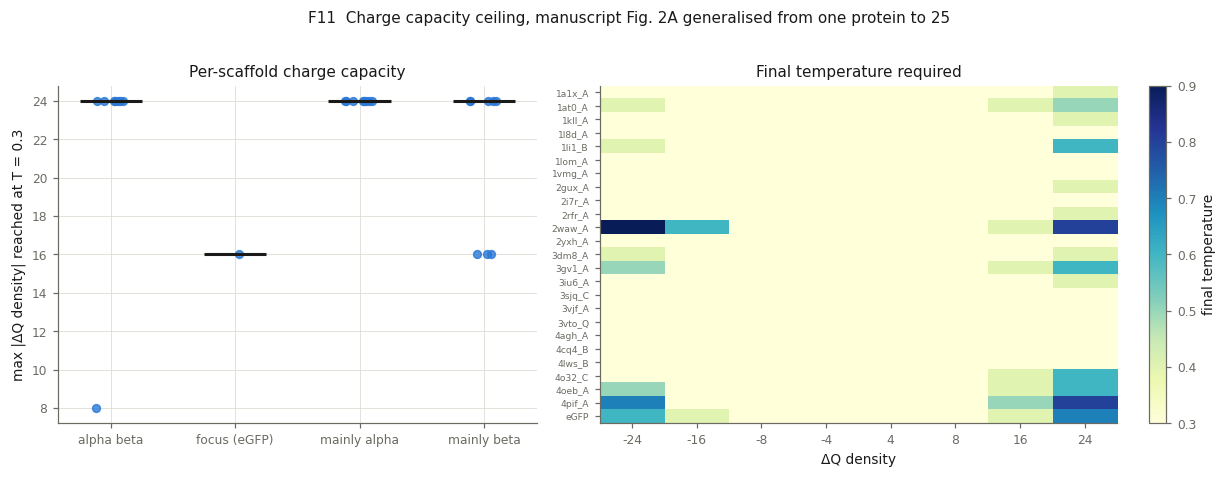

In [22]:
fig = A.fig11(data); A.save(fig, "F11_charge_capacity"); fig

wrote figures/F12_runtime.png and .pdf


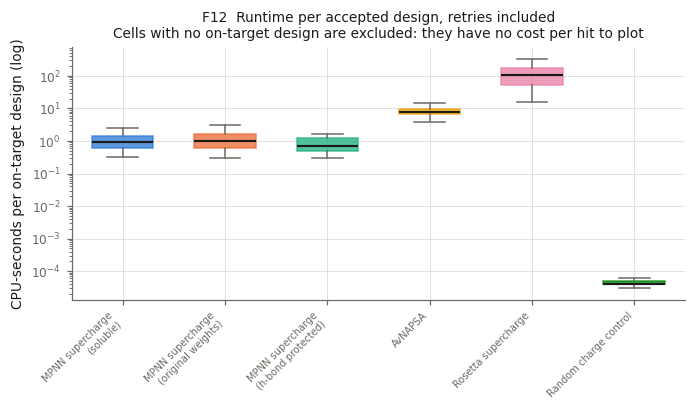

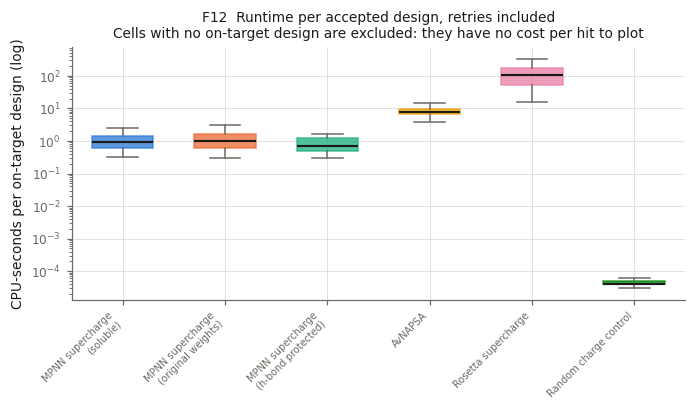

In [23]:
fig = A.fig12(data); A.save(fig, "F12_runtime"); fig

## 11. Sequence selection, corrected (Section 11.3, answers R5)

Reviewer 1 is right that t-SNE distances are not meaningful, and the original
selection was performed in that embedded space. The corrected procedure selects
in the **original BLOSUM62 distance space**: the medoid minimises the summed
distance to all other designs, and the divergent representative maximises its
distance from the medoid. The embedding below is classical MDS (PCoA) and is
**for visualisation only** — it is distance-preserving, which removes the
objection rather than relocating it.

In [24]:
sys.path.insert(0, "../scripts")
from lib import selection as sel
from lib import io as bio

cell = "eGFP_mpnn_soluble_q-25"
native, designs = bio.split_native(bio.parse_fasta(f"../designs/{cell}.fa"))
seqs = [x.sequence for x in designs]
result = sel.select(seqs)
print(f"{cell}: medoid = sample {result['medoid_index']}, "
      f"divergent = sample {result['divergent_index']}")
print("Whether these differ from the manuscript's t-SNE-space selection cannot "
      "be checked here: no record of the original selection exists in this "
      "repository. The corrected indices are reported so the comparison can be "
      "made against the manuscript by hand.")
result

eGFP_mpnn_soluble_q-25: medoid = sample 8, divergent = sample 7
Whether these differ from the manuscript's t-SNE-space selection cannot be checked here: no record of the original selection exists in this repository. The corrected indices are reported so the comparison can be made against the manuscript by hand.


{'n': 10,
 'medoid_index': 8,
 'medoid_distance_sum': 0.4150560559180584,
 'divergent_index': 7,
 'divergent_distance_from_medoid': 0.07105148656893845}

wrote figures/F13_sequence_selection_mds.png and .pdf


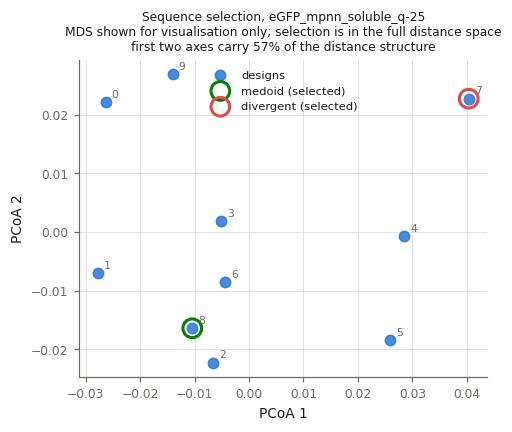

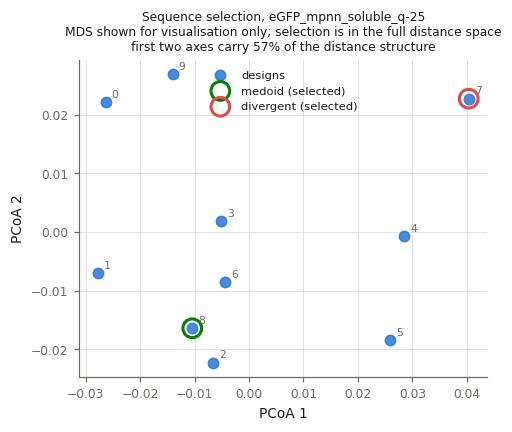

In [25]:
import matplotlib.pyplot as plt

D = sel.distance_matrix(seqs)
coords, eigvals = sel.classical_mds(D)
fig, ax = plt.subplots(figsize=(4.6, 4.0))
ax.scatter(coords[:, 0], coords[:, 1], s=46, color=A.METHOD_COLOR["mpnn_soluble"],
           alpha=0.85, label="designs")
for i, (x, y) in enumerate(coords):
    ax.annotate(str(i), (x, y), fontsize=7, color=A.MUTED,
                xytext=(4, 3), textcoords="offset points")
ax.scatter(*coords[result["medoid_index"]], s=150, facecolor="none",
           edgecolor="#008300", linewidths=2, label="medoid (selected)")
ax.scatter(*coords[result["divergent_index"]], s=150, facecolor="none",
           edgecolor="#e34948", linewidths=2, label="divergent (selected)")
var = eigvals[:2].sum() / np.abs(eigvals).sum()
ax.set_xlabel("PCoA 1"); ax.set_ylabel("PCoA 2")
ax.set_title(f"Sequence selection, {cell}\nMDS shown for visualisation only; "
             f"selection is in the full distance space\n"
             f"first two axes carry {var:.0%} of the distance structure",
             fontsize=8)
ax.legend(frameon=False, fontsize=7.5)
fig.tight_layout()
A.save(fig, "F13_sequence_selection_mds")
fig

## 12. Statistics tables and export

Every test pairs `mpnn_soluble` against one other arm on cells sharing a scaffold
and a target, so the unit of analysis is the scaffold, not the design. Effect
sizes are reported for every test: the median paired difference with a BCa
bootstrap 95% CI and Cliff's delta.

In [26]:
t2 = T.table2(data)
t2

wrote tables/T2b_effect_sizes.csv and .tex  (10 rows)
wrote tables/T2_headline_comparison.csv and .tex  (6 rows)


,method,n_cells,n_designs,hit_rate,mut_per_charge_median,unique_sets_median,pairwise_hamming_median,d_reu_per_res_median,d_hbond_strong_median,d_plddt_vs_wt_median
0,MPNN supercharge (soluble),200,2000,1.000,0.823529,10.0,9.133333,-0.008048,1.0,-1.575825
1,MPNN supercharge (original weights),200,2000,1.000,0.807692,10.0,8.355556,-0.003621,1.0,-1.570694
2,MPNN supercharge (h-bond protected),56,560,1.000,0.826087,10.0,7.066667,-0.012745,5.0,-3.266225
3,AvNAPSA,200,2000,0.593,0.600000,1.0,0.000000,0.028198,-2.0,-0.809509
4,Rosetta supercharge,200,2000,0.232,0.750000,7.0,2.466667,-0.054016,2.0,-0.621726
5,Random charge control,200,2000,1.000,0.823529,10.0,18.122222,0.063488,1.0,-3.226710


In [27]:
t3 = T.table3(data)
t4 = T.table4(data)
t5 = T.table5(data)
t6 = T.table6(data)
t5

wrote tables/T3_egfp_extended.csv and .tex  (48 rows)
wrote tables/T4_af3_subset.csv and .tex  (36 rows)
wrote tables/T5_runtime.csv and .tex  (7 rows)
wrote tables/T6_statistics_full.csv and .tex  (455 rows)


,method,n_cells,cell_seconds_median,cell_seconds_total_h,cells_with_no_hit,seconds_per_on_target_median
0,MPNN supercharge (soluble),200,9.4100,0.658511,0,0.94100
1,MPNN supercharge (original weights),200,9.6650,0.716708,0,0.96650
2,MPNN supercharge (h-bond protected),56,7.0550,0.160008,0,0.70550
3,AvNAPSA,200,73.9450,4.453081,72,7.79400
4,Rosetta supercharge,200,237.5000,16.426508,59,108.31500
5,Random charge control,200,0.0004,0.000024,0,0.00004
6,Vanilla ProteinMPNN + rejection,200,399.5600,2.942211,119,8.61840


In [28]:
stats = data.get("stats")
if stats is not None and len(stats):
    pooled = stats[stats["stratum"] == "all"]
    sig = pooled[pooled["p_holm"] < 0.05]
    print(f"{len(sig)} of {len(pooled)} pooled tests significant at "
          f"Holm-corrected p < 0.05")
    cols = ["metric", "comparison", "n_pairs", "median_diff",
            "ci_low", "ci_high", "cliffs_delta", "p_holm"]
    print(sig[cols].to_string(index=False))
else:
    print("results/statistics.csv absent; run scripts/11_statistics.py")

36 of 55 pooled tests significant at Holm-corrected p < 0.05
                       metric                                   comparison  n_pairs  median_diff    ci_low   ci_high  cliffs_delta       p_holm
                      hit_any                      mpnn_soluble_vs_avnapsa      200     0.360000       NaN       NaN      0.360000 1.905824e-20
                     hit_rate                      mpnn_soluble_vs_avnapsa      200     0.000000       NaN       NaN      0.490000 6.367544e-18
        median_mut_per_charge                      mpnn_soluble_vs_avnapsa      200     0.234393  0.218750  0.250000      0.940975 2.815178e-32
         median_d_reu_per_res                      mpnn_soluble_vs_avnapsa      104    -0.050635 -0.064529 -0.031157     -0.369083 9.910595e-09
        median_d_hbond_strong                      mpnn_soluble_vs_avnapsa      104     2.000000       NaN       NaN      0.424741 4.865193e-09
    median_d_plddt_vs_wt_pred                      mpnn_soluble_vs_avnapsa 

## Caveats carried into the response letter

These are recorded in `logs/ISSUES.md` and are not hidden in the figures:

1. **The wild-type energetic reference relaxes unrestricted** while designs relax
   within the shell around their mutations. This biases ΔREU *against* the
   designs. Both the relaxed and crystal scores are in every reference record.
2. **AvNAPSA's determinism was not measured.** Its diversity metrics are 1 or
   undefined by construction at one design per cell.
3. **Rosetta is not near-deterministic**, contrary to PLAN.md Section 6's
   prediction: a median of 7 distinct mutation sets out of 10.
4. **The hit-rate comparison is budget-sensitive.** AvNAPSA gets one attempt per
   cell and the other arms get ten.
5. **ESMFold used the -Fast model** for the full sweep; AF3 is the high-accuracy
   check on the subset.